# 02 · Quality Control

**Purpose:** Identify and remove units with too much missing data, then interpolate remaining short gaps.

**Input:** `data/output/raw_long_{dataset}.parquet`  
**Output:** `data/output/clean_long_{dataset}.parquet`

**Steps:**
1. Missing value audit — visualise which units and time periods are affected
2. Drop units with > `MISSING_THRESH` missing data (default 20%)
3. Investigate shared outage clusters (units with identical missingness)
4. Drop units with > `ZERO_THRESH` zero values and those showing concept drift
5. Remove units with any NaN streak longer than `NAN_STREAK_DAYS` days
6. Interpolate remaining short gaps (≤ `INTERP_LIMIT` day)
7. Final check and save


In [ ]:
import sys, os

_root = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_root, 'config')) and \
       os.path.isdir(os.path.join(_root, 'utils')):
        break
    _root = os.path.dirname(_root)

sys.path.insert(0, _root)
os.chdir(_root)

from config.settings import cfg, DATASET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

print(f'Root    : {_root}')
print(f'Dataset : {DATASET.upper()}')

Root    : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast
Dataset : LCL


: 

## Load data

In [ ]:
in_path = os.path.join(_root, cfg['OUTPUT_DIR'], f'raw_long_{DATASET}.parquet')
df = pd.read_parquet(in_path)
df['timestamp'] = pd.to_datetime(df['timestamp'])

ID   = cfg['ID_COL']
TIME = 'timestamp'
demand  = cfg['DEMAND_COL']

total_units   = df[ID].nunique()
total_periods = df[TIME].nunique()

print(f'Shape          : {df.shape}')
print(f'Unique units   : {total_units}')
print(f'Time periods   : {total_periods}')
print(f'Date range     : {df[TIME].min()} → {df[TIME].max()}')
print(f'Total NaNs     : {df[demand].isna().sum():,}  ({df[demand].isna().mean()*100:.1f}%)')

## 1 · Missing value audit

In [ ]:
# NaN count and percentage per unit
nan_summary = (
    df.groupby(ID)[demand]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
    .rename('nan_count')
    .to_frame()
)
nan_summary['nan_pct'] = (nan_summary['nan_count'] / total_periods * 100).round(1)

print('Top 20 units by missing data:')
print(nan_summary.head(20).to_string())

Top 20 units by missing data:
        nan_count  nan_pct
chp_id                    
34          16513     79.7
17217        9266     44.7
333          9266     44.7
1968         9266     44.7
46           9266     44.7
19379        9266     44.7
17269        9266     44.7
17768        9266     44.7
22698        9266     44.7
3859         4202     20.3
31574        1035      5.0
257             3      0.0
33436           3      0.0
32              3      0.0
31758           3      0.0
31576           3      0.0
22717           3      0.0
31575           3      0.0
2681            3      0.0
31425           3      0.0


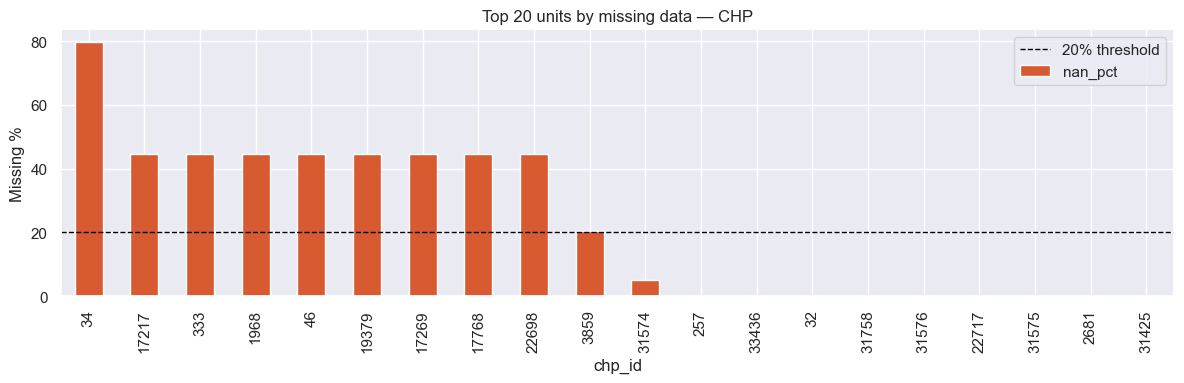

In [ ]:
# Bar chart — top 20 units with most missing values
ax = nan_summary['nan_pct'].head(20).plot(
    kind='bar', figsize=(12, 4), color='#D85A30'
)
ax.axhline(cfg['MISSING_THRESH'] * 100, color='black',
           linestyle='--', linewidth=1, label=f"{cfg['MISSING_THRESH']*100:.0f}% threshold")
ax.set_title(f'Top 20 units by missing data — {DATASET.upper()}')
ax.set_ylabel('Missing %')
ax.set_xlabel(ID)
ax.legend()
plt.tight_layout()
plt.show()

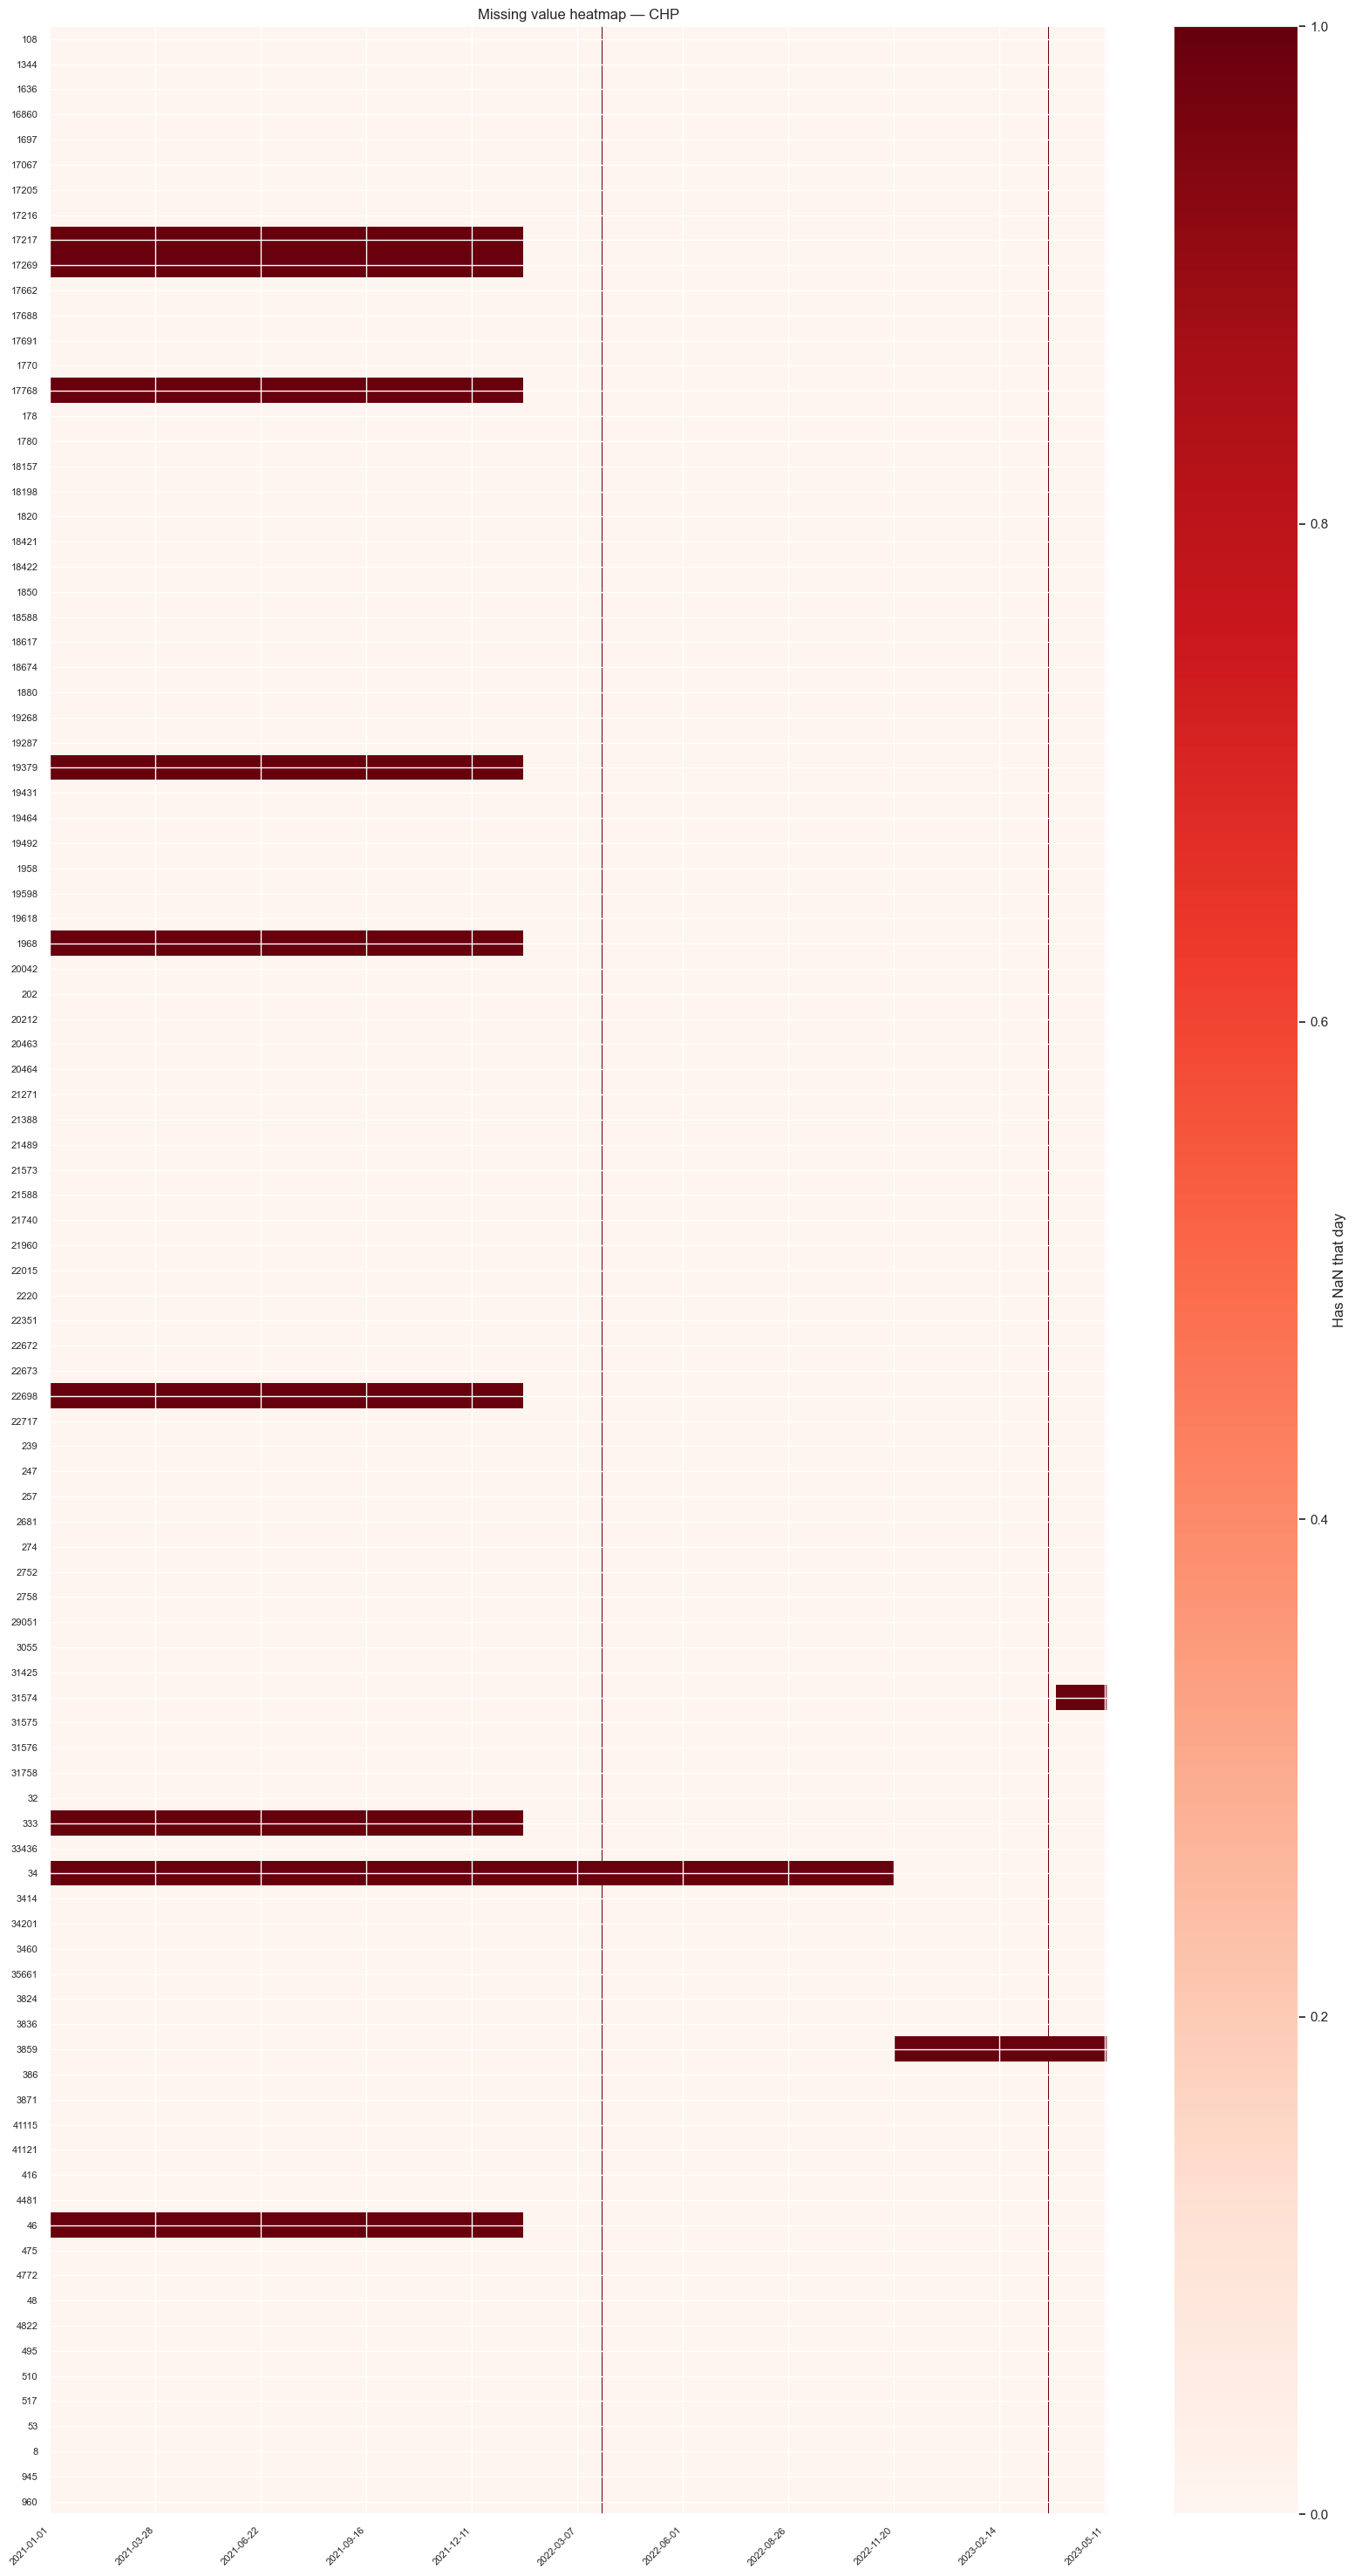

In [ ]:
# Heatmap — missingness over time
# Pivot: rows = units, cols = dates, value = 1 if NaN
df['date'] = df[TIME].dt.date
daily_nan = (
    df[df[demand].isna()]
    .groupby([ID, 'date'])
    .size()
    .unstack(fill_value=0)
    .gt(0)
    .astype(int)
)

if not daily_nan.empty:
    plt.figure(figsize=(16, max(4, len(daily_nan) * 0.3)))
    plt.imshow(daily_nan.values, aspect='auto', interpolation='nearest', cmap='Reds')
    plt.colorbar(label='Has NaN that day')
    plt.yticks(range(len(daily_nan)), daily_nan.index, fontsize=8)
    # x-axis: show ~10 date labels
    n_dates = daily_nan.shape[1]
    step    = max(1, n_dates // 10)
    plt.xticks(
        range(0, n_dates, step),
        [str(daily_nan.columns[i]) for i in range(0, n_dates, step)],
        rotation=45, ha='right', fontsize=8
    )
    plt.title(f'Missing value heatmap — {DATASET.upper()}')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values to plot.')

## 2 · Investigate shared outage clusters

Some units may share identical missing data patterns — this typically indicates a
shared network outage or data collection gap rather than individual meter failures.
The following cell identifies and visualises these clusters.


Units with 40-50% missing: ['17217', '333', '1968', '46', '19379', '17269', '17768', '22698']


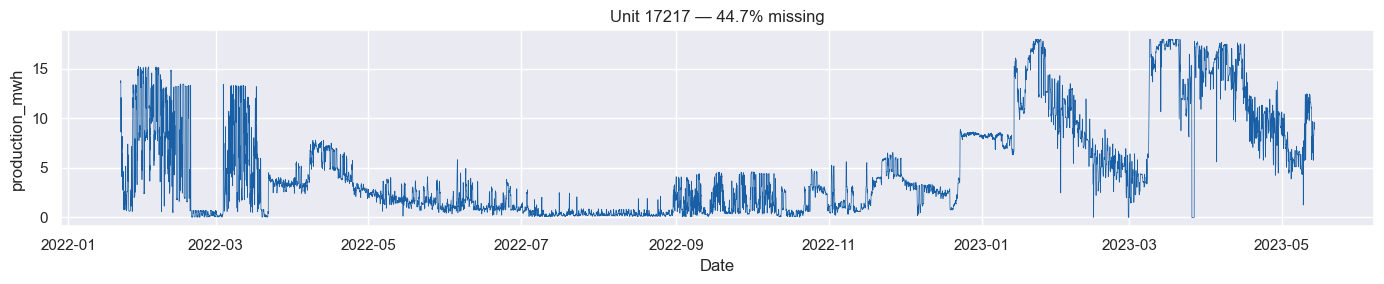

NaN period: 2021-01-01 00:00:00 → 2023-03-26 02:00:00
Duration  : 814 days 02:00:00


In [ ]:
# Find units in the 40-50% missing band
cluster_ids = nan_summary[
    (nan_summary['nan_pct'] >= 40) & (nan_summary['nan_pct'] <= 50)
].index.tolist()

print(f'Units with 40-50% missing: {cluster_ids}')

if cluster_ids:
    # Plot one of them to see where the gap falls
    sample_id  = cluster_ids[0]
    sample_df  = df[df[ID] == sample_id].sort_values(TIME)

    plt.figure(figsize=(14, 3))
    plt.plot(sample_df[TIME], sample_df[demand], linewidth=0.5, color='#185FA5')
    plt.title(f'Unit {sample_id} — {nan_summary.loc[sample_id, "nan_pct"]}% missing')
    plt.xlabel('Date'); plt.ylabel(demand)
    plt.tight_layout()
    plt.show()

    # Show the NaN time range for this unit
    nan_times = sample_df[sample_df[demand].isna()][TIME]
    print(f'NaN period: {nan_times.min()} → {nan_times.max()}')
    print(f'Duration  : {nan_times.max() - nan_times.min()}')

## 3 · Drop units above missing threshold

In [ ]:
threshold    = cfg['MISSING_THRESH']   # 0.20
drop_by_pct  = nan_summary[nan_summary['nan_pct'] > threshold * 100].index.tolist()

print(f'Threshold       : {threshold*100:.0f}%')
print(f'Units to drop   : {len(drop_by_pct)}')
print(f'Dropped IDs     : {drop_by_pct}')

df_step1 = df[~df[ID].isin(drop_by_pct)].copy()
print(f'\nUnits before : {total_units}')
print(f'Units after  : {df_step1[ID].nunique()}')

Threshold       : 20%
Units to drop   : 10
Dropped IDs     : ['34', '17217', '333', '1968', '46', '19379', '17269', '17768', '22698', '3859']

Units before : 99
Units after  : 89


In [ ]:
# Drop units with > 50% zero production
zero_pct = (
    df_step1.groupby(ID)[demand]
    .apply(lambda x: (x == 0).mean())
)
drop_zeros = zero_pct[zero_pct > cfg['ZERO_THRESH']].index.tolist()

print(f'Units dropped (>{cfg["ZERO_THRESH"]*100:.0f}% zeros): {drop_zeros}')
df_step1 = df_step1[~df_step1[ID].isin(drop_zeros)].copy()
print(f'Units remaining: {df_step1[ID].nunique()}')

Units dropped (>50% zeros): ['22717', '3871']
Units remaining: 87


In [ ]:
# Drop units with concept drift — behaviour in test period too different from train
split_date = df_step1['timestamp'].min() + pd.DateOffset(months=12)

train_zero = df_step1[df_step1['timestamp'] <  split_date].groupby(ID)[demand].apply(lambda x: (x==0).mean())
test_zero  = df_step1[df_step1['timestamp'] >= split_date].groupby(ID)[demand].apply(lambda x: (x==0).mean())
drift = (test_zero - train_zero).fillna(0)
drop_drift = drift[
    (test_zero  > cfg['TEST_ZERO_THRESH']) |
    (drift      > cfg['DRIFT_THRESH'])
].index.tolist()
print(f'Split date                              : {split_date}')
print(f'Units dropped (concept drift/test zeros): {len(drop_drift)}')
df_step1 = df_step1[~df_step1[ID].isin(drop_drift)].copy()
print(f'Units remaining                         : {df_step1[ID].nunique()}')

Split date                              : 2022-01-01 00:00:00
Units dropped (concept drift/test zeros): 4
Units remaining                         : 83


## Common Window

In [ ]:
# ── Common window clip ────────────────────────────────────────────────────────
# LCL: WINDOW_START and WINDOW_END are set in config to align all meters to
#      a shared observation period (some meters start/end at different times).
# CHP: WINDOW_START / WINDOW_END are None — use the full available date range.
#      The sweep-line window in notebook 03 will find the common overlap later.

_ws = cfg.get('WINDOW_START')
_we = cfg.get('WINDOW_END')

WINDOW_START = pd.Timestamp(_ws) if _ws else None
WINDOW_END   = pd.Timestamp(_we) if _we else None

if WINDOW_START is not None and WINDOW_END is not None:
    df_step1 = df_step1[
        (df_step1['timestamp'] >= WINDOW_START) &
        (df_step1['timestamp'] <= WINDOW_END)
    ].copy()
    print(f'Window applied : {WINDOW_START} -> {WINDOW_END}')
else:
    print(f'No window set — using full date range (notebook 03 will find common overlap)')

print(f'Units after window step : {df_step1[ID].nunique()}')
print(f'Date range              : {df_step1[TIME].min()} -> {df_step1[TIME].max()}')
print(f'Rows                    : {len(df_step1):,}')

No window set — using full date range (notebook 03 will find common overlap)
Units after window step : 83
Date range              : 2021-01-01 00:00:00 -> 2023-05-13 23:00:00
Rows                    : 1,719,096


## 4 · Remove units with NaN streaks longer than 7 days

In [ ]:
from tqdm import tqdm

# Streak threshold: 7 days worth of periods
PERIODS_PER_DAY  = {'30T': 48, '30min': 48, 'h': 24, 'H': 24, 'D': 1}
ppd              = PERIODS_PER_DAY.get(cfg['FREQ'], 24)
STREAK_THRESHOLD = cfg['NAN_STREAK_DAYS'] * ppd
FREQ_SECONDS     = pd.tseries.frequencies.to_offset(cfg['FREQ']).nanos / 1e9

print(f'Frequency        : {cfg["FREQ"]}')
print(f'Periods per day  : {ppd}')
print(f'Streak threshold : {STREAK_THRESHOLD} periods ({cfg["NAN_STREAK_DAYS"]} days)')

nan_df = df_step1[df_step1[demand].isna()]

def has_long_nan_streak(group):
    group        = group.sort_values(TIME)
    actual_delta = group[TIME].diff().dt.total_seconds()
    group        = group.copy()
    group['gap_block'] = (actual_delta != FREQ_SECONDS).cumsum()
    streaks      = group.groupby('gap_block').size()
    return (streaks >= STREAK_THRESHOLD).any()

# Only check units that have any NaNs
units_with_nans = nan_df[ID].unique()
bad_ids = []
for uid in tqdm(units_with_nans, desc='Checking NaN streaks'):
    group = nan_df[nan_df[ID] == uid]
    if has_long_nan_streak(group):
        bad_ids.append(uid)

print(f'\nUnits with >{cfg["NAN_STREAK_DAYS"]}-day NaN streak : {len(bad_ids)}')
print(f'Dropped IDs : {bad_ids}')

df_step2 = df_step1[~df_step1[ID].isin(bad_ids)].copy()
print(f'\nUnits before : {df_step1[ID].nunique()}')
print(f'Units after  : {df_step2[ID].nunique()}')

Frequency        : h
Periods per day  : 24
Streak threshold : 168 periods (7 days)


Checking NaN streaks: 100%|██████████| 83/83 [00:00<00:00, 1761.76it/s]


Units with >7-day NaN streak : 1
Dropped IDs : ['31574']

Units before : 83
Units after  : 82


## 5 · Interpolate remaining short gaps (≤ 1 day)

In [ ]:
MAX_INTERP = ppd * cfg['INTERP_LIMIT']   # periods in 1 day
print(f'Interpolating gaps up to {cfg["INTERP_LIMIT"]} day ({MAX_INTERP} periods)')
print(f'NaNs before interpolation: {df_step2[demand].isna().sum():,}')

df_step2 = df_step2.sort_values([ID, TIME])
parts    = []

for uid, g in tqdm(
    df_step2.groupby(ID, sort=False),
    total=df_step2[ID].nunique(),
    desc='Interpolating'
):
    g = g.copy().set_index(TIME)
    g[demand] = g[demand].interpolate(method='time', limit=MAX_INTERP)
    parts.append(g.reset_index())

df_clean = pd.concat(parts, ignore_index=True)
print(f'NaNs after interpolation : {df_clean[demand].isna().sum():,}')

Interpolating gaps up to 1 day (24 periods)
NaNs before interpolation: 246


Interpolating: 100%|██████████| 82/82 [00:00<00:00, 570.05it/s]

NaNs after interpolation : 0


## 6 · Final checks

In [ ]:
# Summary of what was removed
print('='*45)
print('Quality control summary')
print('='*45)
print(f'Units in            : {total_units}')
print(f'Dropped >20% NaN    : {len(drop_by_pct)}')
print(f'Dropped >7d streak  : {len(bad_ids)}')
print(f'Units out           : {df_clean[ID].nunique()}')
print(f'Remaining NaNs      : {df_clean[demand].isna().sum():,}')
print(f'Shape out           : {df_clean.shape}')

Quality control summary
Units in            : 99
Dropped >20% NaN    : 10
Dropped >7d streak  : 1
Units out           : 82
Remaining NaNs      : 0
Shape out           : (1698384, 5)


In [ ]:
df_clean

,timestamp,chp_id,production_mwh,capacity_mw,date
0,2021-01-01 00:00:00,1344,9.000,9.000,2021-01-01
1,2021-01-01 01:00:00,1344,9.000,9.000,2021-01-01
2,2021-01-01 02:00:00,1344,9.000,9.000,2021-01-01
3,2021-01-01 03:00:00,1344,8.734,9.000,2021-01-01
4,2021-01-01 04:00:00,1344,8.582,9.000,2021-01-01
...,...,...,...,...,...
1698379,2023-05-13 19:00:00,960,6.221,9.973,2023-05-13
1698380,2023-05-13 20:00:00,960,6.353,9.973,2023-05-13
1698381,2023-05-13 21:00:00,960,6.548,9.973,2023-05-13
1698382,2023-05-13 22:00:00,960,6.178,9.973,2023-05-13


In [ ]:
# Plot remaining NaNs over time — should be minimal after interpolation
remaining_nans = (
    df_clean[df_clean[demand].isna()]
    .groupby('timestamp')[ID]
    .nunique()
    .reset_index(name='units_with_nan')
)

if len(remaining_nans) > 0:
    plt.figure(figsize=(14, 3))
    plt.plot(remaining_nans['timestamp'], remaining_nans['units_with_nan'],
             color='#D85A30', linewidth=1)
    plt.title('Remaining units with missing demand after interpolation')
    plt.xlabel('Date'); plt.ylabel('Units with NaN')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('No remaining NaNs — clean dataset.')

No remaining NaNs — clean dataset.


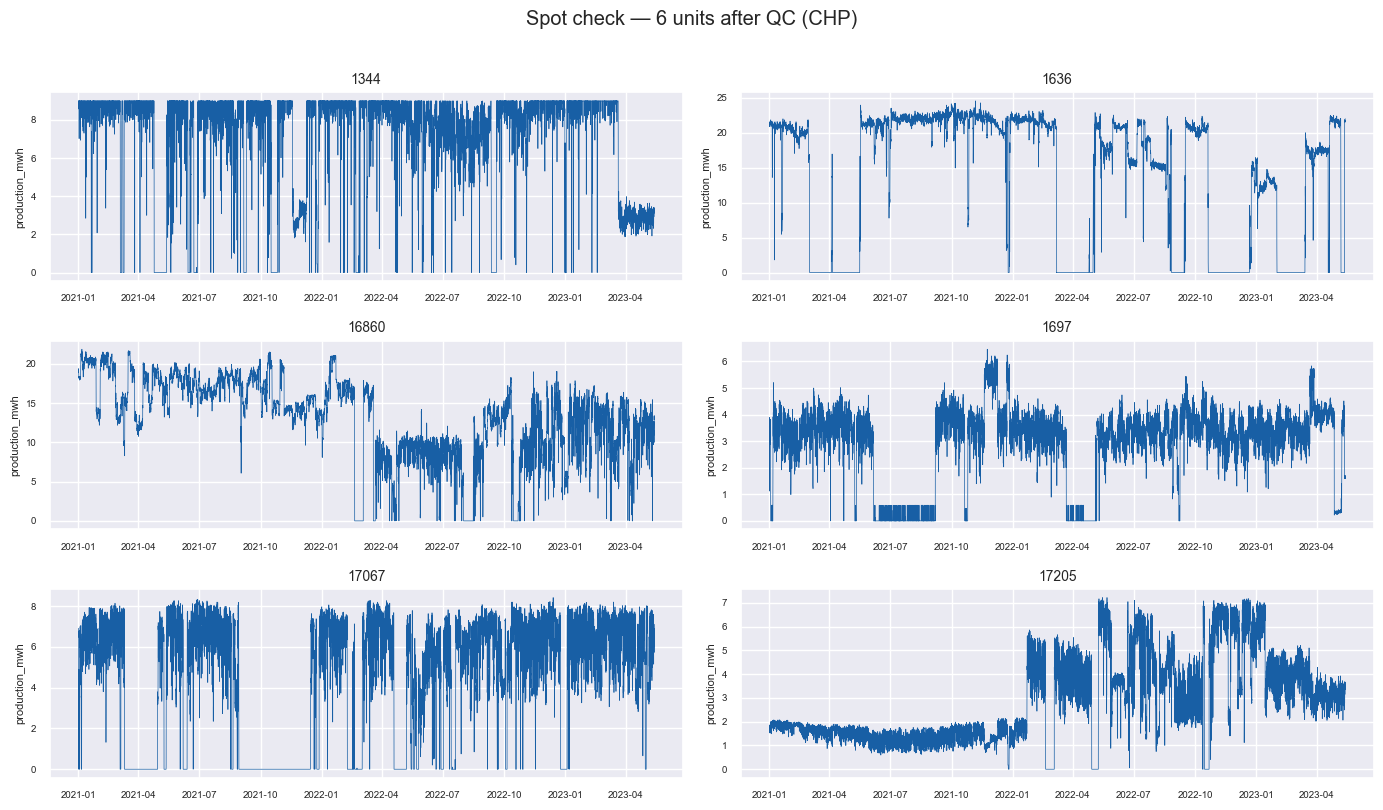

In [ ]:
# Spot check — plot 6 surviving units to confirm they look reasonable
sample_units = df_clean[ID].unique()[:6]
fig, axes    = plt.subplots(3, 2, figsize=(14, 8), sharex=False)

for ax, uid in zip(axes.flat, sample_units):
    sub = df_clean[df_clean[ID] == uid].sort_values(TIME)
    ax.plot(sub[TIME], sub[demand], linewidth=0.5, color='#185FA5')
    ax.set_title(str(uid), fontsize=10)
    ax.set_ylabel(demand, fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle(f'Spot check — 6 units after QC ({DATASET.upper()})', y=1.01)
plt.tight_layout()
plt.show()

## Save

In [ ]:
# Drop helper date column before saving
df_clean = df_clean.drop(columns=['date'], errors='ignore')

out_dir  = os.path.join(_root, cfg['OUTPUT_DIR'])
out_path = os.path.join(out_dir, f'clean_long_{DATASET}.parquet')

df_clean.to_parquet(out_path, index=False)
print(f'Saved → {out_path}  ({os.path.getsize(out_path)/1e6:.1f} MB)')

# Read-back check
check = pd.read_parquet(out_path)
print(f'Read-back shape : {check.shape}')
print(f'Read-back NaNs  : {check[demand].isna().sum():,}')
check.head(3)

Saved → /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/clean_long_chp.parquet  (6.6 MB)
Read-back shape : (1698384, 4)
Read-back NaNs  : 0


,timestamp,chp_id,production_mwh,capacity_mw
0,2021-01-01 00:00:00,1344,9.0,9.0
1,2021-01-01 01:00:00,1344,9.0,9.0
2,2021-01-01 02:00:00,1344,9.0,9.0
